In [2]:
##
import pandas as pd
import matplotlib.pyplot as plt
df= pd.read_csv("../datasets/processed/erc_20/processed_token_transfers.csv")

In [4]:
df.head()

,block_number,transaction_index,from_address,to_address,time_stamp,contract_address,value,date
0,14669683,7,0xd30b438df65f4f788563b2b3611bd6059bff4ad9,0xda816e2122a8a39b0926bfa84edd3d42477e9efd,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,18.670000,2022-04-28 00:30:15
1,14669683,45,0x4941834ed1428089ee76252f6f9d767e800499b0,0x28c6c06298d514db089934071355e5743bf21d60,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,10000.000000,2022-04-28 00:30:15
2,14669683,46,0x2c1f9a20711e14f8484a41123e20d1b06858ebea,0x28c6c06298d514db089934071355e5743bf21d60,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,9942.313005,2022-04-28 00:30:15
3,14669683,47,0x7784c4f53aa5f03bd6d3ca670c9d9c887cc38cb0,0x3cd751e6b0078be393132286c442345e5dc49699,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,234.364097,2022-04-28 00:30:15
4,14669683,48,0x66589b8278470d58d4112f3d065de0f75734312e,0x28c6c06298d514db089934071355e5743bf21d60,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,9800.000000,2022-04-28 00:30:15


In [5]:
df.groupby(["block_number", "transaction_index"]).size()




block_number  transaction_index
14669683      1                    1
              7                    1
              9                    1
              33                   1
              45                   1
                                  ..
14843502      152                  1
              181                  1
              183                  1
14843503      2                    1
              4                    1
Length: 4468270, dtype: int64

In [6]:
actions = (
    df.groupby(["block_number", "transaction_index"])
      .agg(
          n_events=("value", "size"),
          total_value=("value", "sum"),
          unique_tokens=("contract_address", "nunique"),
          unique_receivers=("to_address", "nunique"),
          first_time=("date", "min")
      )
      .reset_index()
)

In [7]:
actions["first_time"] = pd.to_datetime(actions["first_time"])

collapse_time = pd.Timestamp("2022-05-09 12:00")  
start_time = collapse_time - pd.Timedelta(days=20)

subset = actions[
    (actions["first_time"] >= start_time) &
    (actions["first_time"] <= collapse_time)
].copy()


In [8]:
subset["hour"] = subset["first_time"].dt.floor("h")

hourly_counts = (
    subset.groupby("hour")
          .size()
          .rename("n_actions")
          .reset_index()
)
hourly_complexity = (
    subset.groupby("hour")["n_events"]
    
          .mean()
          .reset_index(name="avg_events_per_action")
)
hourly = hourly_counts.merge(hourly_complexity, on="hour", how="inner")
hourly = hourly.sort_values("hour")

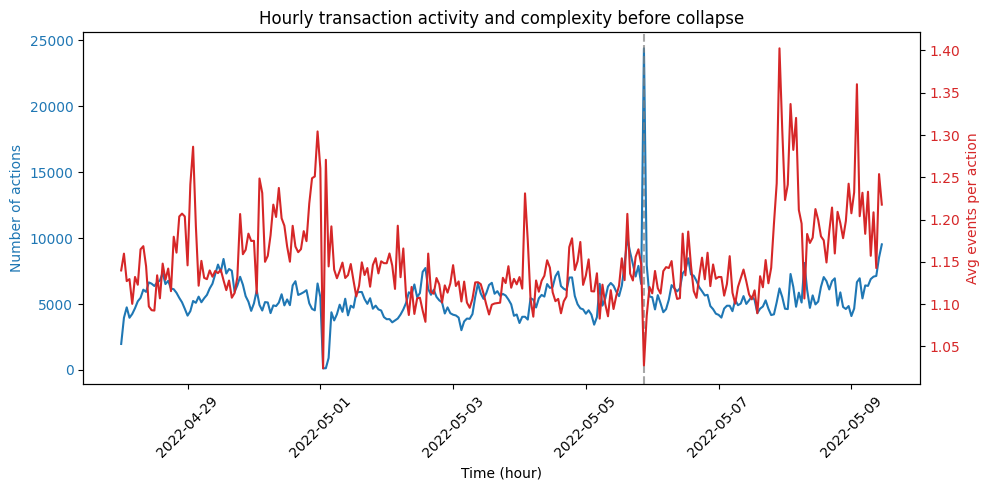

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: number of actions
ax1.plot(
    hourly["hour"],
    hourly["n_actions"],
    label="Number of actions",
    color="tab:blue"
)
ax1.set_xlabel("Time (hour)")
ax1.set_ylabel("Number of actions", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.tick_params(axis="x", rotation=45)

# Right axis: average events per action (complexity)
ax2 = ax1.twinx()
ax2.plot(
    hourly["hour"],
    hourly["avg_events_per_action"],
    label="Avg events per action",
    color="tab:red"
)
ax2.set_ylabel("Avg events per action", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Optional: mark peak hour
peak_hour = hourly.loc[hourly["n_actions"].idxmax(), "hour"]
ax1.axvline(peak_hour, linestyle="--", color="grey", alpha=0.7)

# Title and layout
plt.title("Hourly transaction activity and complexity before collapse")
fig.tight_layout()
plt.show()

In [10]:
## exact max hour
peak_row = hourly_counts.loc[hourly_counts["n_actions"].idxmax()]
peak_time = peak_row["hour"]
peak_actions = int(peak_row["n_actions"])
peak_time, peak_actions

(Timestamp('2022-05-05 21:00:00'), 24384)

In [11]:
df.head()

,block_number,transaction_index,from_address,to_address,time_stamp,contract_address,value,date
0,14669683,7,0xd30b438df65f4f788563b2b3611bd6059bff4ad9,0xda816e2122a8a39b0926bfa84edd3d42477e9efd,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,18.670000,2022-04-28 00:30:15
1,14669683,45,0x4941834ed1428089ee76252f6f9d767e800499b0,0x28c6c06298d514db089934071355e5743bf21d60,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,10000.000000,2022-04-28 00:30:15
2,14669683,46,0x2c1f9a20711e14f8484a41123e20d1b06858ebea,0x28c6c06298d514db089934071355e5743bf21d60,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,9942.313005,2022-04-28 00:30:15
3,14669683,47,0x7784c4f53aa5f03bd6d3ca670c9d9c887cc38cb0,0x3cd751e6b0078be393132286c442345e5dc49699,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,234.364097,2022-04-28 00:30:15
4,14669683,48,0x66589b8278470d58d4112f3d065de0f75734312e,0x28c6c06298d514db089934071355e5743bf21d60,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,9800.000000,2022-04-28 00:30:15


In [ ]:
#df2 = pd.read_csv("../datasets/processed/erc_20/processed_token_transfers_V2.0.0.csv")


In [ ]:
#df2.head()

In [ ]:
#df2.shape

(28674511, 8)

In [ ]:
##scratch this
actions2 = (
    df2.groupby(["block_number", "transaction_index"], sort=False)
       .agg(
           n_events=("value", "size"),
           total_value=("value", "sum"),
           unique_tokens=("contract_address", "nunique"),
           unique_receivers=("to_address", "nunique"),
           first_time=("date", "min")
       )
       .reset_index()
)

In [20]:
IN_PATH  = "../datasets/processed/erc_20/processed_token_transfers_V3.0.0.csv"
OUT_PATH = "../datasets/processed/erc_20/token3_apr1_to_may9.csv"

usecols = [
    "block_number", "transaction_index",
    "from_address", "to_address",
    "time_stamp", "contract_address",
    "value"
]

# UTC window
start_ts = int(pd.Timestamp("2022-04-01 00:00:00", tz="UTC").timestamp())
end_ts   = int(pd.Timestamp("2022-05-09 23:59:59", tz="UTC").timestamp())

first_write = True
for chunk in pd.read_csv(IN_PATH, usecols=usecols, chunksize=2_000_000):
    # filter early by unix timestamp (fast)
    chunk = chunk[(chunk["time_stamp"] >= start_ts) & (chunk["time_stamp"] <= end_ts)]
    if chunk.empty:
        continue

    # rebuild date (UTC) AFTER filtering
    chunk["date"] = pd.to_datetime(chunk["time_stamp"], unit="s", utc=True)

    # append to output file
    chunk.to_csv(OUT_PATH, mode="w" if first_write else "a",
                 index=False, header=first_write)
    first_write = False

print("Done. Saved:", OUT_PATH)

Done. Saved: ../datasets/processed/erc_20/token3_apr1_to_may9.csv


In [5]:
token3 = pd.read_csv(
    "../datasets/processed/erc_20/token3_apr1_to_may9.csv",
    parse_dates=["date"]
)

token3.shape, token3["date"].min(), token3["date"].max()

((5683403, 8),
 Timestamp('2022-04-01 11:10:21+0000', tz='UTC'),
 Timestamp('2022-05-09 23:59:29+0000', tz='UTC'))

In [6]:
actions3 = (
    token3
      .groupby(["block_number", "transaction_index"], sort=False)
      .agg(
          n_events=("value", "size"),
          total_value=("value", "sum"),
          unique_tokens=("contract_address", "nunique"),
          unique_receivers=("to_address", "nunique"),
          first_time=("date", "min")
      )
      .reset_index()
)

In [7]:
collapse_time = pd.Timestamp("2022-05-09 12:00:00", tz="UTC")
start_time = collapse_time - pd.Timedelta(days=30)

subset3 = actions3[
    (actions3["first_time"] >= start_time) &
    (actions3["first_time"] <= collapse_time)
].copy()

In [9]:
subset3["hour"] = subset3["first_time"].dt.floor("h")

hourly_counts3 = (
    subset3.groupby("hour")
            .size()
            .rename("n_actions")
            .reset_index()
)

hourly_complexity3 = (
    subset3.groupby("hour")["n_events"]
            .mean()
            .reset_index(name="avg_events_per_action")
)

hourly3 = hourly_counts3.merge(hourly_complexity3, on="hour").sort_values("hour")

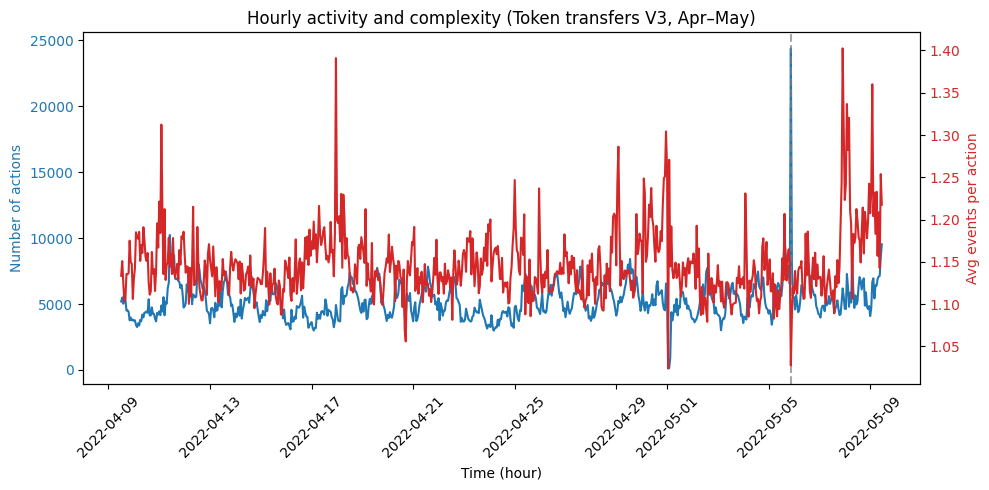

In [10]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(hourly3["hour"], hourly3["n_actions"], color="tab:blue", label="Number of actions")
ax1.set_xlabel("Time (hour)")
ax1.set_ylabel("Number of actions", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(hourly3["hour"], hourly3["avg_events_per_action"], color="tab:red", label="Avg events per action")
ax2.set_ylabel("Avg events per action", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

peak_hour3 = hourly3.loc[hourly3["n_actions"].idxmax(), "hour"]
ax1.axvline(peak_hour3, linestyle="--", color="grey", alpha=0.7)

plt.title("Hourly activity and complexity (Token transfers V3, Apr–May)")
fig.tight_layout()
plt.show()

In [11]:
token3["contract_address"].value_counts().head(20)

contract_address
0xdac17f958d2ee523a2206206994597c13d831ec7    3112632
0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48    2155389
0x6b175474e89094c44da98b954eedeac495271d0f     312832
0xa47c8bf37f92abed4a126bda807a7b7498661acd      75135
0xd2877702675e6ceb975b4a1dff9fb7baf4c91ea9      17853
0x8e870d67f660d95d5be530380d0ec0bd388289e1       9562
Name: count, dtype: int64

In [12]:
UST_ADDRESS = "0xa47c8bf37f92abed4a126bda807a7b7498661acd"
ust = token3[token3["contract_address"] == UST_ADDRESS].copy()

In [21]:
ZERO_ADDRESS = "0x0000000000000000000000000000000000000000"

ust_clean = ust[
    (ust["from_address"] != ZERO_ADDRESS) &
    (ust["to_address"]   != ZERO_ADDRESS)
].copy()

In [22]:
ust_clean["hour"] = ust_clean["date"].dt.floor("h")

hourly_ust_volume_clean = (
    ust_clean.groupby("hour")["value"]
             .sum()
             .reset_index(name="ust_volume")
             .sort_values("hour")
)

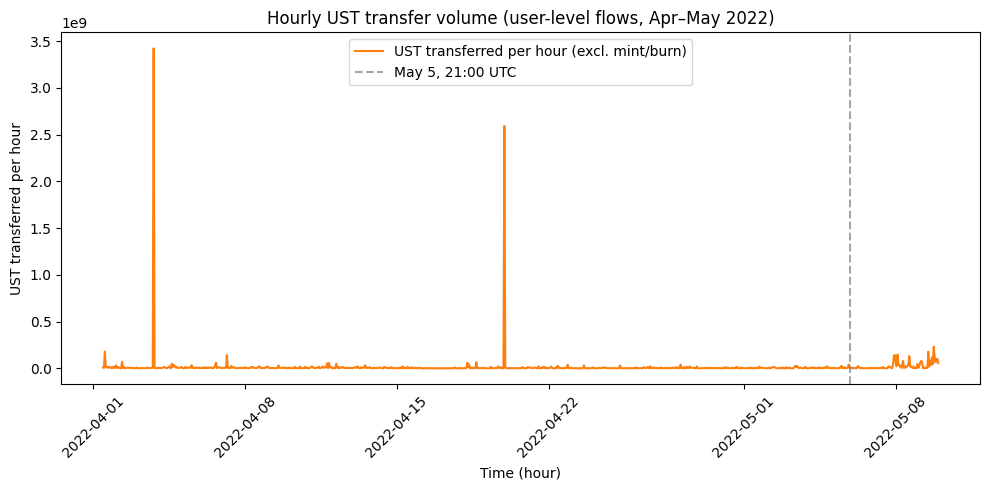

In [23]:
peak_time = pd.Timestamp("2022-05-05 21:00:00", tz="UTC")

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_ust_volume_clean["hour"],
    hourly_ust_volume_clean["ust_volume"],
    color="tab:orange",
    label="UST transferred per hour (excl. mint/burn)"
)

plt.axvline(
    peak_time,
    linestyle="--",
    color="grey",
    alpha=0.7,
    label="May 5, 21:00 UTC"
)

plt.xlabel("Time (hour)")
plt.ylabel("UST transferred per hour")
plt.title("Hourly UST transfer volume (user-level flows, Apr–May 2022)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
ust_clean["value"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    5.737700e+04
mean     2.401905e+05
std      7.987714e+06
min      0.000000e+00
50%      6.377501e+03
90%      2.500000e+05
95%      6.076276e+05
99%      2.000001e+06
max      7.134947e+08
Name: value, dtype: float64

In [ ]:
#implementing the cap??
cap = ust_clean["value"].quantile(0.99)

ust_behavioral = ust_clean[ust_clean["value"] <= cap].copy()

In [ ]:
cap = ust_clean["value"].quantile(0.99)

ust_behavioral = ust_clean[ust_clean["value"] <= cap].copy()

In [28]:
ust_behavioral["hour"] = ust_behavioral["date"].dt.floor("h")

hourly_ust_volume_behavioral = (
    ust_behavioral.groupby("hour")["value"]
                   .sum()
                   .reset_index(name="ust_volume")
                   .sort_values("hour")
)

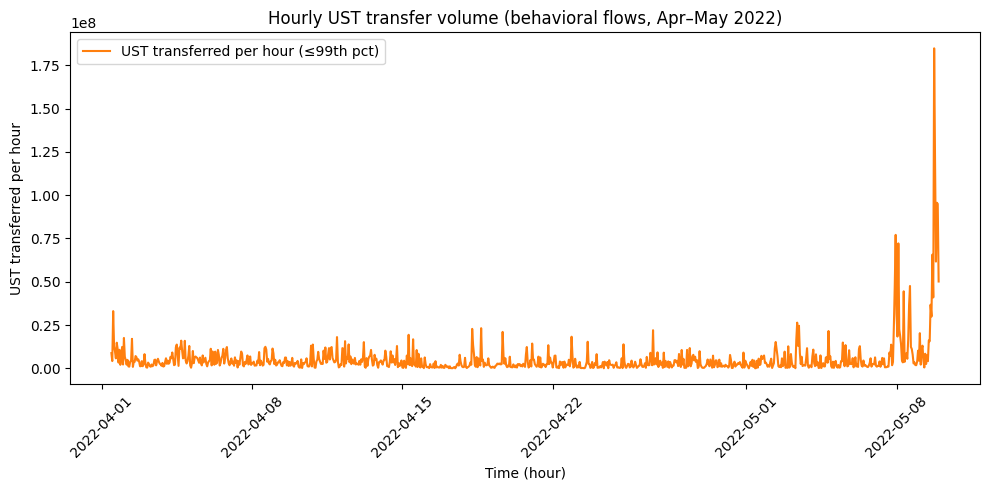

In [31]:


peak_time = pd.Timestamp("2022-05-05 21:00:00", tz="UTC")

plt.figure(figsize=(10, 5))
plt.plot(
    hourly_ust_volume_behavioral["hour"],
    hourly_ust_volume_behavioral["ust_volume"],
    color="tab:orange",
    label="UST transferred per hour (≤99th pct)"
)

#plt.axvline(
    #peak_time,
    #linestyle="--",
    #color="grey",
    #alpha=0.7,
    #label="May 5, 21:00 UTC"
#)

plt.xlabel("Time (hour)")
plt.ylabel("UST transferred per hour")
plt.title("Hourly UST transfer volume (behavioral flows, Apr–May 2022)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()